In [ ]:
!pip install seaborn
!pip install pydot graphviz

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

df = pd.read_csv('/content/Final_IMDB_Dataset.csv')

# View the first 10 rows of the dataset
print("First 10 rows of the dataset :\n")
print(df.head(10))

First 10 rows of the dataset :

      tconst                          primaryTitle  \
0  tt0000574           The Story of the Kelly Gang   
1  tt0000591                      The Prodigal Son   
2  tt0000679        The Fairylogue and Radio-Plays   
3  tt0001184               Don Juan de Serrallonga   
4  tt0001285                     The Life of Moses   
5  tt0001498               The Battle of Trafalgar   
6  tt0001592                  In the Prime of Life   
7  tt0001790  Les Misérables, Part 1: Jean Valjean   
8  tt0001812                           Oedipus Rex   
9  tt0001892                        Den sorte drøm   

                             originalTitle  year  runtimeMinutes  \
0              The Story of the Kelly Gang  1906              70   
1                        L'enfant prodigue  1907              90   
2           The Fairylogue and Radio-Plays  1908             120   
3                  Don Juan de Serrallonga  1910              58   
4                        The Life

In [ ]:
# Number of rows and columns
print("Shape of the Dataset :")
print(df.shape)

# Dataset summary
print("\nDataset Summary :\n")
df.info()

Shape of the Dataset :
(214926, 17)

Dataset Summary :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214926 entries, 0 to 214925
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tconst          214926 non-null  object 
 1   primaryTitle    214926 non-null  object 
 2   originalTitle   214926 non-null  object 
 3   year            214926 non-null  int64  
 4   runtimeMinutes  214926 non-null  int64  
 5   genres          214926 non-null  object 
 6   genre1          214926 non-null  object 
 7   genre2          118486 non-null  object 
 8   genre3          55893 non-null   object 
 9   averageRating   214926 non-null  float64
 10  numVotes        214926 non-null  int64  
 11  directors       213964 non-null  object 
 12  directorName    213961 non-null  object 
 13  writers         201548 non-null  object 
 14  writerNames     201547 non-null  object 
 15  topActorIDs     214926 non-null  object 
 16  

In [ ]:
# No target column
target_col = None

# Classification based on data types
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Columns that are lists stored as strings.
multilabel_cols = ['genres', 'directorName', 'actorNames', 'writerNames']

for col in multilabel_cols:
    if col in categorical_cols:
        categorical_cols.remove(col)

# Final classified columns
print(f"Target Column : {target_col}")
print(f"Numerical Columns ({len(numerical_cols)}) : {numerical_cols}")
print(f"Categorical Columns ({len(categorical_cols)}) : {categorical_cols}")
print(f"Multi-label Columns ({len(multilabel_cols)}) : {multilabel_cols}")

Target Column : None
Numerical Columns (4) : ['year', 'runtimeMinutes', 'averageRating', 'numVotes']
Categorical Columns (9) : ['tconst', 'primaryTitle', 'originalTitle', 'genre1', 'genre2', 'genre3', 'directors', 'writers', 'topActorIDs']
Multi-label Columns (4) : ['genres', 'directorName', 'actorNames', 'writerNames']


In [ ]:
# Handling Missing Values

# Missing Values in each column
missing_values = df.isnull().sum()
print("Missing values per column :\n")
print(missing_values)


print("\nPercentage of Missing values per column :\n")
print((missing_values / len(df)) * 100)

Missing values per column :

tconst                 0
primaryTitle           0
originalTitle          0
year                   0
runtimeMinutes         0
genres                 0
genre1                 0
genre2             96440
genre3            159033
averageRating          0
numVotes               0
directors            962
directorName         965
writers            13378
writerNames        13379
topActorIDs            0
actorNames             0
dtype: int64

Percentage of Missing values per column :

tconst             0.000000
primaryTitle       0.000000
originalTitle      0.000000
year               0.000000
runtimeMinutes     0.000000
genres             0.000000
genre1             0.000000
genre2            44.871258
genre3            73.994305
averageRating      0.000000
numVotes           0.000000
directors          0.447596
directorName       0.448992
writers            6.224468
writerNames        6.224933
topActorIDs        0.000000
actorNames         0.000000
dtype: float6

In [ ]:
# Fill missing secondary genres with 'None'
df['genre2'] = df['genre2'].fillna('None')
df['genre3'] = df['genre3'].fillna('None')

# Check genre distribution
print(df['genre1'].value_counts().head(10))
print('\n', df['genre2'].value_counts().head(10))
print('\n', df['genre3'].value_counts().head(10))

genre1
Drama          69035
Comedy         53737
Action         25232
Crime          11834
Horror          9865
Adventure       9811
Documentary     9291
Biography       4625
Adult           3539
Thriller        3512
Name: count, dtype: int64

 genre2
None         96440
Drama        35089
Romance      15204
Crime         8243
Thriller      7921
Comedy        7281
Horror        6002
Adventure     5513
Family        4913
Mystery       4696
Name: count, dtype: int64

 genre3
None        159033
Romance      10616
Thriller      9710
Drama         7547
Mystery       3730
Fantasy       2671
Family        2661
Sci-Fi        2563
War           2212
Horror        2169
Name: count, dtype: int64


In [ ]:
# Drop rows where 'directorName' is missing
df = df[~df['directorName'].isnull()]

# Fill missing writers and writerNames with 'Unknown'
df['writers'] = df['writers'].fillna('Unknown')
df['writerNames'] = df['writerNames'].fillna('Unknown')

# Re-check for Missing Values
print("Missing values :\n")
print(df.isnull().sum())

Missing values :

tconst            0
primaryTitle      0
originalTitle     0
year              0
runtimeMinutes    0
genres            0
genre1            0
genre2            0
genre3            0
averageRating     0
numVotes          0
directors         0
directorName      0
writers           0
writerNames       0
topActorIDs       0
actorNames        0
dtype: int64


In [ ]:
# Handling Duplicate Rows

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows : {duplicates}")

# Check for duplicate tconst entries (MovieIDs)
duplicate_tconst = df['tconst'].duplicated().sum()
print(f"Number of duplicate tconst entries : {duplicate_tconst}")

Number of duplicate rows : 0
Number of duplicate tconst entries : 0


Summary Statistics for Runtime (in minutes) :

count    213961.000000
mean         95.657185
std         101.900005
min           2.000000
25%          83.000000
50%          92.000000
75%         104.000000
90%         122.000000
95%         138.000000
99%         168.000000
max       43200.000000
Name: runtimeMinutes, dtype: float64



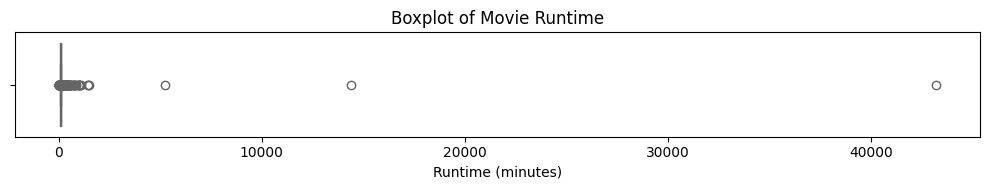


Outlier Threshold Calculation using IQR Method :

IQR (Q3 - Q1) :              21.00
Lower Bound (Q1 - 3.5 X IQR) : 9.50
Upper Bound (Q3 + 3.5 X IQR) : 177.50



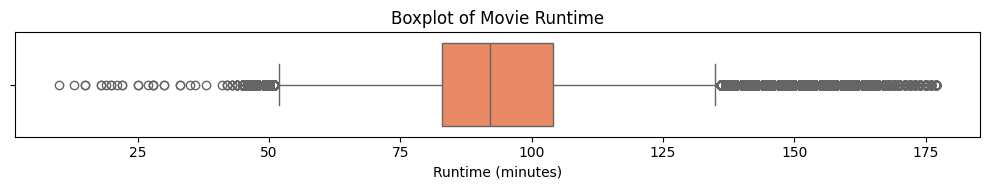

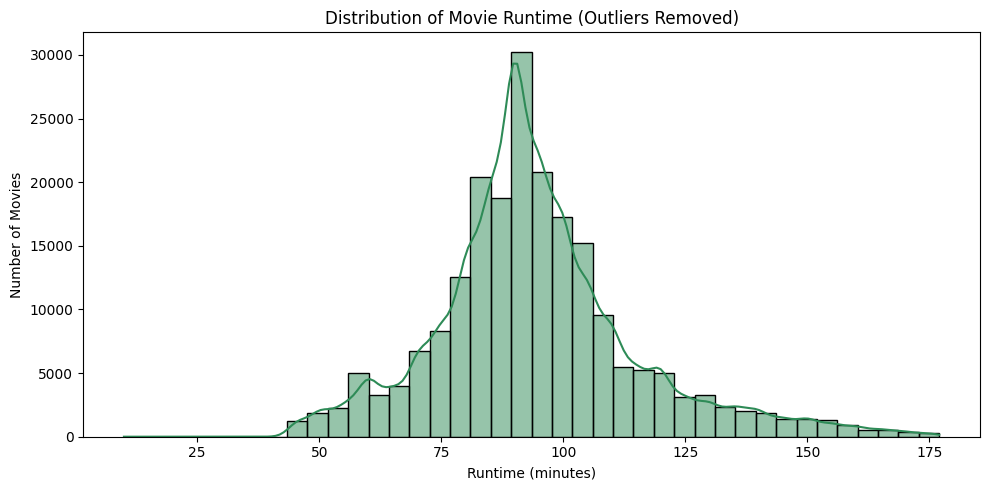

In [ ]:
# Outlier Treatment

# Display key descriptive statistics for runtimeMinutes
print("Summary Statistics for Runtime (in minutes) :\n")
print(df['runtimeMinutes'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))

print()

# Visualize the runtime distribution using a boxplot to identify outliers
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['runtimeMinutes'], color='coral')
plt.title('Boxplot of Movie Runtime')
plt.xlabel('Runtime (minutes)')
plt.tight_layout()
plt.show()

print()

# Define bounds for outlier removal using IQR method
Q1 = df['runtimeMinutes'].quantile(0.25)
Q3 = df['runtimeMinutes'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3.5 * IQR
upper_bound = Q3 + 3.5 * IQR

# Print calculated statistical values
print("Outlier Threshold Calculation using IQR Method :\n")
print(f"IQR (Q3 - Q1) :              {IQR:.2f}")
print(f"Lower Bound (Q1 - 3.5 X IQR) : {lower_bound:.2f}")
print(f"Upper Bound (Q3 + 3.5 X IQR) : {upper_bound:.2f}")
print()

# Filter out outliers from the runtime column
df_filtered_runtime = df[(df['runtimeMinutes'] >= lower_bound) & (df['runtimeMinutes'] <= upper_bound)]

# Boxplot after removing outliers
plt.figure(figsize=(10, 2))
sns.boxplot(x=df_filtered_runtime['runtimeMinutes'], color='coral')
plt.title('Boxplot of Movie Runtime')
plt.xlabel('Runtime (minutes)')
plt.tight_layout()
plt.show()

print()

# Plot the distribution of runtime after removing outliers
plt.figure(figsize=(10, 5))
sns.histplot(df_filtered_runtime['runtimeMinutes'], bins=40, kde=True, color='seagreen')
plt.title('Distribution of Movie Runtime (Outliers Removed)')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

# Overwrite the original DataFrame to exclude runtime outliers
df = df_filtered_runtime.copy()

In [ ]:
# Convert Data Types
import ast

# Convert list-like strings to actual lists
for col in multilabel_cols:
    df[col] = df[col].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith('[') else x
    )

# Ensure 'startYear' and 'runtimeMinutes' are numeric
df['startYear'] = pd.to_numeric(df['year'], errors='coerce')
df['runtimeMinutes'] = pd.to_numeric(df['runtimeMinutes'], errors='coerce')

# Feature Extraction

# Create a 'decade' column
df['decade'] = (df['year'] // 10) * 10
df['decade_label'] = df['decade'].astype(str) + '–' + ((df['decade'] % 100 + 9).astype(str).str.zfill(2))

# IMDb Weighted Rating calculation

# Set the vote threshold
m = df['numVotes'].quantile(0.90)  # Top 10% most voted movies
C = df['averageRating'].mean()     # Mean average rating across all movies

print("Weighted Rating (WR) Calculation :")
print(f"Global Mean Rating (C)     : {C:.2f}")
print(f"Minimum Votes Required (m) : {m:.0f}")

# Function to calculate IMDb weighted rating
def weighted_rating(x, m=m, C=C):
    v = x['numVotes']
    R = x['averageRating']
    return (v / (v + m)) * R + (m / (v + m)) * C

# Apply the formula to all movies
df['weightedRating'] = df.apply(weighted_rating, axis=1) / 10

Weighted Rating (WR) Calculation :
Global Mean Rating (C)     : 5.98
Minimum Votes Required (m) : 2533


In [ ]:
# Normalize / Scale Numerical Features

from sklearn.preprocessing import MinMaxScaler

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Apply scaling to selected numeric columns
df[[ 'runtimeMinutes_scaled', "year_scaled"]] = scaler.fit_transform(
    df[['runtimeMinutes', 'year']]
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 212536 entries, 0 to 214925
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   tconst                 212536 non-null  object 
 1   primaryTitle           212536 non-null  object 
 2   originalTitle          212536 non-null  object 
 3   year                   212536 non-null  int64  
 4   runtimeMinutes         212536 non-null  int64  
 5   genres                 212536 non-null  object 
 6   genre1                 212536 non-null  object 
 7   genre2                 212536 non-null  object 
 8   genre3                 212536 non-null  object 
 9   averageRating          212536 non-null  float64
 10  numVotes               212536 non-null  int64  
 11  directors              212536 non-null  object 
 12  directorName           212536 non-null  object 
 13  writers                212536 non-null  object 
 14  writerNames            212536 non-null  o

In [ ]:
# Copy the original df into a new df
cleaned_df = df.copy()

# Function to remove whitespaces and replace with underscores
def clean_cell(cell):
    if isinstance(cell, list):
        # Clean each item in the list
        return [item.strip().replace(' ', '_') for item in cell if isinstance(item, str)]
    elif isinstance(cell, str):
        # Clean the string (comma-separated case)
        return ','.join([item.strip().replace(' ', '_') for item in cell.split(',')])
    return cell  # for NaN or other types

# Columns to be cleaned
columns_to_clean = ['directorName', 'actorNames', 'genres']

# Apply the cleaning
for col in columns_to_clean:
    cleaned_df[col] = cleaned_df[col].apply(clean_cell)

In [ ]:
# Export the cleaned dataset
cleaned_df.to_csv("cleaned_df.csv", index=False)

In [ ]:
# Function to weight the categorical attributes and join them to form a string
def create_weighted_soup(row, director_wt=4):
    # Genre weights: genre1 (3), genre2 (2), genre3 (1)
    genre_tokens = []
    if isinstance(row['genres'], str):
        genre_parts = row['genres'].lower().split(',')
        for i, wt in zip(range(len(genre_parts)), [12, 8, 0]):
            if i < len(genre_parts):
                genre = genre_parts[i].strip()
                genre_tokens.extend([genre] * wt)

    # Director (uniform weight)
    director_tokens = []
    if isinstance(row['directorName'], str):
        director = row['directorName'].strip().lower()
        director_tokens = [director] * director_wt

    # Actor weights: actor1 (3), actor2 (2), actor3 (1)
    actor_tokens = []
    if isinstance(row['actorNames'], list):
        for i, wt in zip(range(len(row['actorNames'])), [7, 7, 2]):
            if i < len(row['actorNames']):
                actor = row['actorNames'][i].strip().lower()
                actor_tokens.extend([actor] * wt)

    # Combine all tokens, remove short tokens (length <= 2)
    tokens = genre_tokens + director_tokens + actor_tokens
    clean_tokens = [tok for tok in tokens if len(tok) > 2]

    # Combine all tokens into the final soup string
    return ' '.join(clean_tokens)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# Function to calculate the distance for the 3 numerical attributes
def calculate_distance(match_row, row):
    year_diff = abs(match_row['year'] - row['year'])
    year_diff_scaled = abs(match_row['year_scaled'] - row['year_scaled'])
    rating_diff = abs(match_row['weightedRating'] - row['weightedRating'])
    runtime_diff = abs(match_row['runtimeMinutes_scaled'] - row['runtimeMinutes_scaled'])

    distance = 0

    # Customized for the people who like to watch short films (runtime <= 60 mins)
    if match_row['runtimeMinutes'] <= 60:
      distance = year_diff_scaled * 0.15 + rating_diff * 0.15 + runtime_diff * 0.7

    #Weights of year and ratings changes as per the value of year

    else:
      if year_diff <= 5:
        distance = year_diff_scaled * 0.5 + rating_diff * 0.35 + runtime_diff * 0.15
      elif year_diff <= 15:
        distance = year_diff_scaled * 0.4 + rating_diff * 0.45 + runtime_diff * 0.15
      else:
        distance = year_diff_scaled * 0.25 + rating_diff * 0.6 + runtime_diff * 0.15

    return distance
#

In [ ]:
# Function to calculate the cosine similarity for the nominal attributes
def calculate_cosine_similarity(matched_row, row):
    cos_sim = cosine_similarity(matched_row, row)
    return cos_sim[0][0]

In [ ]:
# Final function that returns the recommended movies
def get_enhanced_recommendations(title, year, top_n=100):

    # Change title to lower case and year to int data type
    title = title.strip().lower()
    year = int(year)

    # Step 1: Prepare DataFrame and TF-IDF matrix
    new_df = cleaned_df.copy().reset_index(drop=True)
    new_df['primaryTitle_clean'] = new_df['primaryTitle'].astype(str).str.strip().str.lower()
    new_df['soup'] = new_df.apply(create_weighted_soup, axis=1)

    vectorizer = TfidfVectorizer(stop_words='english')
    term_freq_matrix = vectorizer.fit_transform(new_df['soup'])

    # Step 2: Find matching movie and its index in dataset
    matches = new_df[(new_df['primaryTitle_clean'] == title) & (new_df['startYear'] == year)]

    if matches.empty:
        return f"❌ No movie titled '{title}' from year {year} found in the dataset."

    print("Matched movie info:\n", matches[['primaryTitle', 'startYear', 'directorName', 'actorNames', 'soup']])

    match_idx = matches.index[0]
    match_row = new_df.loc[match_idx]

    # Step 3: Compute similarity and distance
    similarities = []
    for idx, row in new_df.iterrows():
        if idx == match_idx:
            continue  # Skip the matched movie itself

        # Compute numerical distance-based similarity
        num_sim = calculate_distance(match_row, row)

        # Compute TF-IDF cosine similarity
        vector_row = term_freq_matrix[idx]
        cos_sim = calculate_cosine_similarity(term_freq_matrix[match_idx], vector_row)

        # Combined similarity (controls weight of cosine vs numerical)
        combined_score = 0.6 * cos_sim + 0.4 * (1 - num_sim)

        similarities.append({
            'index': idx,
            'combined_sim': combined_score,
            'cosine_sim': cos_sim,
            'distance': num_sim
        })

    # Step 4: Build result DataFrame from top N
    sim_df = pd.DataFrame(similarities)
    top_indices = sim_df.sort_values(by='combined_sim', ascending=False).head(top_n)['index']

    result_df = new_df.loc[top_indices, [
        'primaryTitle', 'directorName', 'actorNames',
        'genre1', 'genre2', 'genre3', 'weightedRating', 'runtimeMinutes', 'year'
    ]].copy()

    # Add similarity columns
    result_df['distance'] = sim_df.set_index('index').loc[result_df.index]['distance'].values
    result_df['cosine_sim'] = sim_df.set_index('index').loc[result_df.index]['cosine_sim'].values
    result_df['combined_sim'] = sim_df.set_index('index').loc[result_df.index]['combined_sim'].values

    return result_df.reset_index(drop=True)

In [ ]:
df_recommended = get_enhanced_recommendations("Singham Returns", 2014, 10)
df_recommended

Matched movie info:
            primaryTitle  startYear  directorName  \
161769  Singham Returns       2014  Rohit_Shetty   

                                       actorNames  \
161769  [Ajay_Devgn, Kareena_Kapoor, Amole_Gupte]   

                                                     soup  
161769  action action action action action action acti...  


,primaryTitle,directorName,actorNames,genre1,genre2,genre3,weightedRating,runtimeMinutes,year,distance,cosine_sim,combined_sim
0,Golmaal Returns,Rohit_Shetty,"[Ajay_Devgn, Kareena_Kapoor, Arshad_Warsi]",Comedy,Crime,Mystery,0.531387,135,2008,0.047195,0.875722,0.906555
1,Omkara,Vishal_Bhardwaj,"[Ajay_Devgn, Kareena_Kapoor, Saif_Ali_Khan]",Action,Crime,Drama,0.786700,155,2006,0.133936,0.820261,0.838582
2,Golmaal 3,Rohit_Shetty,"[Mithun_Chakraborty, Ajay_Devgn, Kareena_Kapoor]",Action,Comedy,None,0.561149,155,2010,0.034226,0.702873,0.808033
3,Singham,Rohit_Shetty,"[Ajay_Devgn, Prakash_Raj, Sudhanshu_Pandey]",Action,Crime,Drama,0.669104,143,2011,0.046306,0.626857,0.757592
4,All the Best: Fun Begins,Rohit_Shetty,"[Sanjay_Dutt, Ajay_Devgn, Fardeen_Khan]",Action,Comedy,Drama,0.606520,144,2009,0.033920,0.579795,0.734309
5,Golmaal Again,Rohit_Shetty,"[Ajay_Devgn, Arshad_Warsi, Tabu]",Action,Comedy,Fantasy,0.513264,140,2017,0.036795,0.558974,0.720666
6,Sunday,Rohit_Shetty,"[Ajay_Devgn, Ayesha_Takia, Arshad_Warsi]",Action,Comedy,Mystery,0.567705,135,2008,0.030851,0.539585,0.711410
7,Zameen,Rohit_Shetty,"[Ajay_Devgn, Abhishek_Bachchan, Bipasha_Basu]",Action,Adventure,Thriller,0.575702,154,2003,0.048985,0.550359,0.710621
8,Golmaal: Fun Unlimited,Rohit_Shetty,"[Ajay_Devgn, Arshad_Warsi, Sharman_Joshi]",Action,Comedy,Drama,0.721394,150,2006,0.100058,0.557138,0.694260
9,Jung,Rama_Rao_Tatineni,"[Mithun_Chakraborty, Ajay_Devgn, Rambha]",Action,Crime,Drama,0.581418,146,1996,0.045448,0.499290,0.681394
